# Crude Supply-Demand Balance & Inventory Shock Study

Objective: evaluate whether EIA inventory and Cushing shocks transmit into WTI volatility and the Brent-WTI spread. The analysis combines weekly physical petroleum balances with daily spot-market outcomes. This is **not** price prediction.

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

from build_balance import build_crude_balance
from build_features import FUNDAMENTAL_FEATURES, PRICE_FEATURES, build_features, compute_shock_zscore
from event_study import run_all_event_studies, run_event_study
from fetch_eia import fetch_all_eia
from fetch_prices import fetch_daily_prices
from figures import (
    plot_extreme_bar,
    plot_event_study_comparison,
    plot_inventory_seasonality,
    plot_price_history,
    plot_spread,
)

In [2]:
prices = fetch_daily_prices(start="2010-01-01")
print(prices.shape)
print(prices.index.min(), prices.index.max())
prices.tail(5)

Daily prices: 4,126 rows, 2010-01-04 to 2026-06-15
(4126, 2)
2010-01-04 00:00:00 2026-06-15 00:00:00


,wti_price,brent_price
date,,
2026-06-09,91.90,94.15
2026-06-10,93.68,95.73
2026-06-11,91.58,92.84
2026-06-12,88.62,88.64
2026-06-15,84.65,84.36


In [3]:
eia = fetch_all_eia(start="2010-01-01")
print(eia.shape)
print(eia.index.min(), eia.index.max())
eia.tail(5)

WCESTUS1 -> us_crude_stocks: 859 rows, 2010-01-01 to 2026-06-12


W_EPC0_SAX_YCUOK_MBBL -> cushing_stocks: 859 rows, 2010-01-01 to 2026-06-12


WCRSTUS1 -> us_crude_production: 859 rows, 2010-01-01 to 2026-06-12


WCRIMUS2 -> crude_imports: 859 rows, 2010-01-01 to 2026-06-12


WCREXUS2 -> crude_exports: 859 rows, 2010-01-01 to 2026-06-12


WGIRIUS2 -> refinery_inputs: 859 rows, 2010-01-01 to 2026-06-12


WPULEUS3 -> refinery_utilization: 859 rows, 2010-01-01 to 2026-06-12
Merged EIA weekly: 859 rows, 2010-01-01 to 2026-06-12
(859, 7)
2010-01-01 00:00:00 2026-06-12 00:00:00


,us_crude_stocks,cushing_stocks,us_crude_production,crude_imports,crude_exports,refinery_inputs,refinery_utilization
week_end,,,,,,,
2026-05-15,445013,25818,819188,6016,5604,16642,91.6
2026-05-22,441686,23024,806798,5212,4440,17171,94.5
2026-05-29,433712,22441,790831,6397,5874,17199,94.7
2026-06-05,426485,21640,775677,5888,4840,17315,95.3
2026-06-12,418222,20034,758473,5134,4327,17415,96.7


In [4]:
balance = build_crude_balance(eia)
balance[[
    "crude_supply",
    "crude_demand",
    "crude_balance",
    "inventory_change",
    "balance_residual",
]].describe()

Crude balance: 858 rows, 2010-01-08 to 2026-06-12


,crude_supply,crude_demand,crude_balance,inventory_change,balance_residual
count,8.580000e+02,858.000000,8.580000e+02,858.000000,8.580000e+02
mean,1.029590e+06,17985.752914,1.011604e+06,130.065268,1.011474e+06
std,1.249860e+05,2202.874007,1.262376e+05,4987.949348,1.261092e+05
min,7.636070e+05,12651.000000,7.418650e+05,-17049.000000,7.501280e+05
25%,9.723900e+05,16050.250000,9.528302e+05,-3244.250000,9.494115e+05
50%,1.062168e+06,17818.000000,1.045498e+06,336.500000,1.045234e+06
75%,1.112619e+06,20026.000000,1.093983e+06,3049.750000,1.093399e+06
max,1.235528e+06,23073.000000,1.218150e+06,21563.000000,1.217297e+06


The weekly physical balance is approximated as crude supply minus crude demand, where supply is domestic production plus imports and demand is exports plus refinery inputs. Inventory change is the observed stock movement. The residual compares the flow balance with reported inventory change, which is useful because it checks whether the market story is grounded in physical barrels rather than only prices.

In [5]:
merged = build_features(balance, prices)
feature_names = [c for c in FUNDAMENTAL_FEATURES + PRICE_FEATURES if c in merged.columns]
print(len(feature_names), feature_names)
print(merged.shape)
merged.tail(5)

Merged event table: 858 rows, 2010-01-08 to 2026-06-12
Feature count: 19
Features: inventory_change, cushing_change, production_change, net_import_change, refinery_util_change, crude_balance, inventory_shock_z, cushing_shock_z, production_shock_z, days_of_supply_z, top_decile_inventory_draw, top_decile_inventory_build, top_decile_cushing_draw, top_decile_cushing_build, brent_wti_spread, spread_zscore, trailing_20d_vol, wti_return, fwd_5d_realized_vol
19 ['inventory_change', 'cushing_change', 'production_change', 'net_import_change', 'refinery_util_change', 'crude_balance', 'inventory_shock_z', 'cushing_shock_z', 'production_shock_z', 'days_of_supply_z', 'top_decile_inventory_draw', 'top_decile_inventory_build', 'top_decile_cushing_draw', 'top_decile_cushing_build', 'brent_wti_spread', 'spread_zscore', 'trailing_20d_vol', 'wti_return', 'fwd_5d_realized_vol']
(858, 37)


,us_crude_stocks,cushing_stocks,us_crude_production,crude_imports,crude_exports,refinery_inputs,refinery_utilization,inventory_change,cushing_change,crude_supply,...,wti_price,brent_price,brent_wti_spread,wti_return,trailing_20d_vol,spread_zscore,fwd_5d_realized_vol,fwd_5d_spread_change,fwd_5d_wti_return,date
week_end,,,,,,,,,,,,,,,,,,,,,
2026-05-15,445013,25818,819188,6016,5604,16642,91.6,-7863.0,-1604.0,825204,...,100.20,105.84,5.64,-0.014761,0.625420,NaN,0.383458,-3.92,-0.094552,2026-05-21
2026-05-22,441686,23024,806798,5212,4440,17171,94.5,-3327.0,-2794.0,812010,...,92.65,95.47,2.82,0.003243,0.586972,NaN,0.513067,-0.67,0.044128,2026-05-28
2026-05-29,433712,22441,790831,6397,5874,17199,94.7,-7974.0,-583.0,797228,...,96.83,98.98,2.15,-0.029810,0.554513,NaN,0.363953,-0.89,-0.055744,2026-06-04
2026-06-05,426485,21640,775677,5888,4840,17315,95.3,-7227.0,-801.0,781565,...,91.58,92.84,1.26,-0.022672,0.546193,NaN,NaN,NaN,NaN,2026-06-11
2026-06-12,418222,20034,758473,5134,4327,17415,96.7,-8263.0,-1606.0,763607,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


Release-date alignment maps each weekly EIA observation to the nearest daily trading date around an approximate release date of four business days after the week end. Daily forward outcomes are computed before the merge. That ordering prevents look-ahead bias because the event row only receives price outcomes that were already defined on the daily price table.

In [6]:
plot_price_history(prices)

WindowsPath('outputs/figures/01_price_history.png')

In [7]:
plot_spread(prices)

WindowsPath('outputs/figures/02_brent_wti_spread.png')

In [8]:
plot_inventory_seasonality(balance)

WindowsPath('outputs/figures/03_inventory_seasonality.png')

In [9]:
results = run_all_event_studies(merged)
results

                                           title         shock_col          outcome_col                                            study  n_draws  n_builds  mean_outcome_after_draw  mean_outcome_after_build  difference  t_statistic  p_value  significant_5pct
 Inventory Draw vs Build -> WTI 5-day Volatility inventory_shock_z  fwd_5d_realized_vol  Inventory Draw vs Build -> WTI 5-day Volatility       83        83                 0.308937                  0.405572   -0.096635    -1.745087 0.083853             False
Cushing Draw vs Build -> Brent-WTI Spread Change   cushing_shock_z fwd_5d_spread_change Cushing Draw vs Build -> Brent-WTI Spread Change       83        83                -0.201687                  0.065542   -0.267229    -0.950343 0.343343             False
     Inventory Draw vs Build -> WTI 5-day Return inventory_shock_z    fwd_5d_wti_return      Inventory Draw vs Build -> WTI 5-day Return       83        83                -0.004747                 -0.001127   -0.003620    -

,title,shock_col,outcome_col,study,n_draws,n_builds,mean_outcome_after_draw,mean_outcome_after_build,difference,t_statistic,p_value,significant_5pct
0,Inventory Draw vs Build -> WTI 5-day Volatility,inventory_shock_z,fwd_5d_realized_vol,Inventory Draw vs Build -> WTI 5-day Volatility,83,83,0.308937,0.405572,-0.096635,-1.745087,0.083853,False
1,Cushing Draw vs Build -> Brent-WTI Spread Change,cushing_shock_z,fwd_5d_spread_change,Cushing Draw vs Build -> Brent-WTI Spread Change,83,83,-0.201687,0.065542,-0.267229,-0.950343,0.343343,False
2,Inventory Draw vs Build -> WTI 5-day Return,inventory_shock_z,fwd_5d_wti_return,Inventory Draw vs Build -> WTI 5-day Return,83,83,-0.004747,-0.001127,-0.003620,-0.375079,0.708159,False


In [10]:
plot_extreme_bar(
    merged,
    "inventory_shock_z",
    "fwd_5d_realized_vol",
    "Inventory Shock and Forward WTI Volatility",
    "Annualized realized volatility",
    "04_inventory_shock_volatility.png",
)
fig = plot_event_study_comparison(
    merged,
    "inventory_shock_z",
    "fwd_5d_realized_vol",
    "5-Day WTI Realized Volatility After Extreme Inventory Shocks",
    "Annualized Volatility",
)
plt.close(fig)

In [11]:
plot_extreme_bar(
    merged,
    "cushing_shock_z",
    "fwd_5d_spread_change",
    "Cushing Shock and Forward Brent-WTI Spread",
    "5-day spread change, USD per barrel",
    "05_cushing_shock_spread.png",
)
fig = plot_event_study_comparison(
    merged,
    "cushing_shock_z",
    "fwd_5d_spread_change",
    "5-Day Brent-WTI Spread Change After Extreme Cushing Shocks",
    "Spread Change ($/bbl)",
)
plt.close(fig)

In [12]:
key_features = [
    "inventory_change",
    "inventory_shock_z",
    "cushing_shock_z",
    "crude_balance",
    "balance_residual",
    "days_of_supply",
    "brent_wti_spread",
    "trailing_20d_vol",
    "fwd_5d_realized_vol",
    "fwd_5d_spread_change",
    "fwd_5d_wti_return",
]
summary_stats = merged[key_features].describe().T
summary_stats.to_csv(ROOT / "outputs" / "tables" / "summary_statistics.csv")
summary_stats.to_csv(ROOT / "outputs" / "tables" / "feature_summary_stats.csv")
summary_stats

,count,mean,std,min,25%,50%,75%,max
inventory_change,858.0,1.300653e+02,4987.949348,-17049.000000,-3244.250000,3.365000e+02,3.049750e+03,2.156300e+04
inventory_shock_z,833.0,-5.805364e-03,1.022787,-3.497054,-0.720492,-9.102209e-03,6.575751e-01,3.356252e+00
cushing_shock_z,833.0,-1.365767e-02,1.042134,-3.153428,-0.742120,-4.239432e-02,6.874387e-01,3.686609e+00
crude_balance,858.0,1.011604e+06,126237.598261,741865.000000,952830.250000,1.045498e+06,1.093983e+06,1.218150e+06
balance_residual,858.0,1.011474e+06,126109.191295,750128.000000,949411.500000,1.045234e+06,1.093399e+06,1.217297e+06
days_of_supply,858.0,1.813974e+02,27.177633,137.163136,159.883152,1.795939e+02,1.947606e+02,3.293432e+02
brent_wti_spread,855.0,6.048667e+00,5.777283,-4.940000,2.380000,4.420000e+00,7.675000e+00,2.894000e+01
trailing_20d_vol,850.0,3.438469e-01,0.222546,0.112839,0.229809,2.906906e-01,4.053017e-01,2.765226e+00
fwd_5d_realized_vol,855.0,3.304872e-01,0.277378,0.036391,0.186829,2.719725e-01,3.828096e-01,3.236514e+00
fwd_5d_spread_change,852.0,3.920188e-03,1.837584,-12.160000,-0.870000,-2.000000e-02,8.725000e-01,8.170000e+00


Inventory draws are negative stock changes and generally indicate a tighter physical crude market, while builds suggest looser conditions. Large draws can matter for volatility because they may force traders to reassess near-term balances quickly. Cushing is especially important for WTI because it is the delivery hub embedded in the benchmark's physical settlement logic. When Cushing inventories tighten, the Brent-WTI spread can react differently from broad U.S. stock changes. The event-study comparisons here are best read as diagnostics of market transmission, not a forecasting model. Statistical significance depends on the sample, the release-date approximation, and the fact that no consensus expectations are included. The results therefore describe historical conditional averages, not a trading rule.

Limitations: the release date is approximated, not pulled from the actual EIA release calendar. The study does not include survey expectations, so it measures raw shocks rather than surprises relative to market consensus. It does not include the futures curve, options-implied volatility, refinery outages, storage constraints, or macro news controls. Forward returns and volatility are short-horizon realized outcomes, not tradable forecasts. This is not a trading strategy.

## Risk Overlay: GARCH/VaR Analysis

To complement the fundamental event-study analysis, we fit GARCH-family volatility models to WTI daily returns and construct a 99% 1-day Value-at-Risk framework.

This bridges the gap between **commodity fundamentals** (what drives volatility) and **market risk measurement** (how to quantify downside exposure).

In [13]:
from risk_overlay import run_risk_overlay

risk_results = run_risk_overlay()
print("\n=== Model Comparison (by AIC) ===")
print(risk_results["comparison"].to_string(index=False))
print(f"\nBest model: {risk_results['best_model_key']}")

WTI returns: 4,124 rows, 2010-01-05 to 2026-06-15, mean=0.000009, std=0.029864
GARCH_normal: loglik=-8968.81, AIC=17945.61, BIC=17970.91, params=4
GARCH_t: loglik=-8825.08, AIC=17660.16, BIC=17691.78, params=5
GJR_normal: loglik=-8957.21, AIC=17924.42, BIC=17956.05, params=5
GJR_t: loglik=-8818.65, AIC=17649.29, BIC=17687.24, params=6
Best model: GJR_t (AIC=17649.3)


Backtest: 27 breaches in 4124 days (0.655% vs 1.0% target)
Kupiec p-value: 0.0174

=== Model Comparison (by AIC) ===
       model  log_likelihood          aic          bic  num_params
       GJR_t    -8818.647432 17649.294863 17687.242337           6
     GARCH_t    -8825.079643 17660.159285 17691.782180           5
  GJR_normal    -8957.212385 17924.424771 17956.047665           5
GARCH_normal    -8968.807008 17945.614016 17970.912331           4

Best model: GJR_t


In [14]:
import json
print("=== VaR Backtest (Kupiec POF) ===")
for k, v in risk_results["backtest"].items():
    print(f"  {k}: {v}")

=== VaR Backtest (Kupiec POF) ===
  total_observations: 4124
  num_breaches: 27
  breach_rate_pct: 0.655
  expected_rate_pct: 1.0
  LR_statistic: 5.6567
  p_value: 0.0174
  reject_H0_5pct: True
  interpretation: Breach rate significantly differs from 1% target


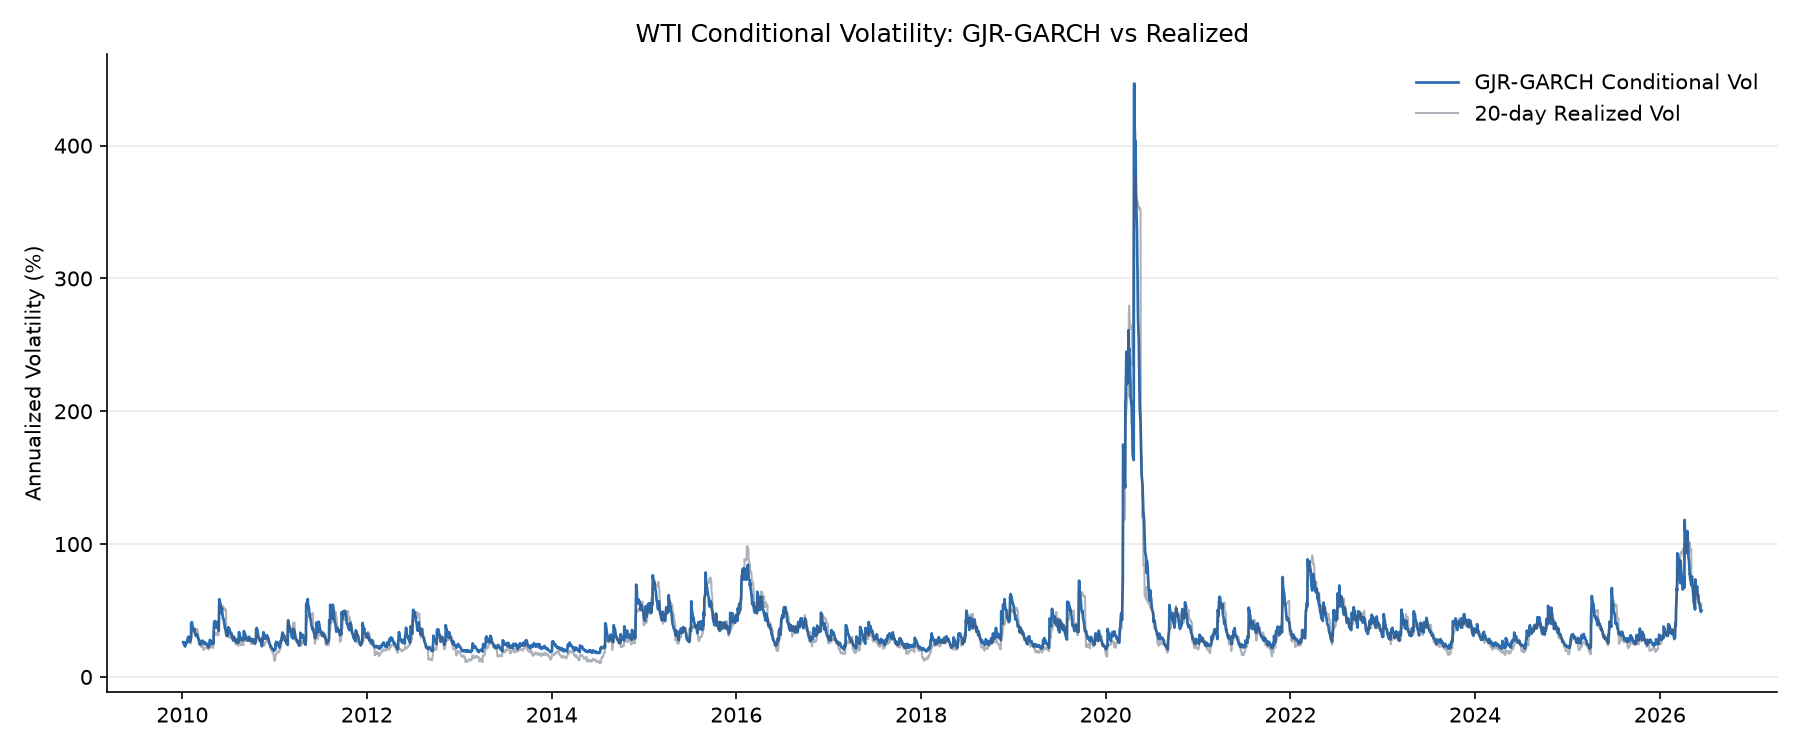

In [15]:
from IPython.display import Image
Image(filename="outputs/figures/06_conditional_volatility.png")

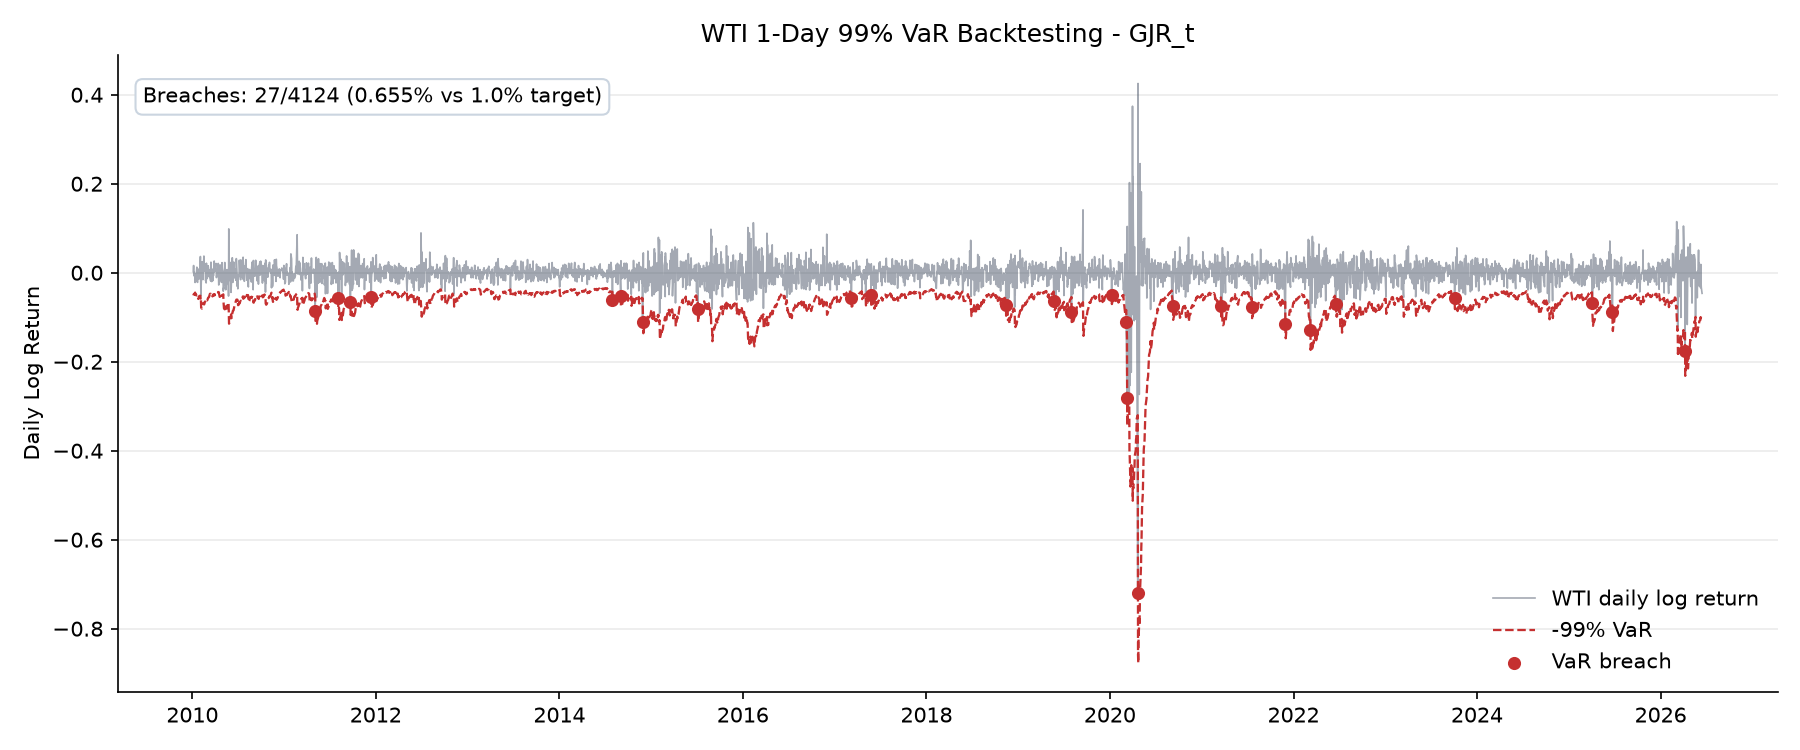

In [16]:
Image(filename="outputs/figures/07_var_breaches.png")

### Risk Overlay Interpretation

- The **GJR-GARCH(1,1) with Student-t errors** fits best in this sample, capturing both volatility clustering and asymmetric volatility response.
- Student-t errors accommodate the heavy tails observed in commodity returns, producing more conservative VaR estimates than Gaussian assumptions.
- The Kupiec POF test evaluates whether the observed breach rate is statistically consistent with the 1% target.
- This risk overlay connects to the fundamental analysis: inventory shocks that elevate realized volatility should also show up as periods of elevated GARCH conditional volatility and tighter VaR thresholds.

## Weekly Analyst Memo

A commodity research analyst's core output is translating fundamental data into market judgment. This section demonstrates automated memo generation from the pipeline's quantitative signals.

The memo template follows industry convention: EIA release summary table, supply-demand balance assessment, bullish/bearish tone with supporting evidence, spread and volatility regime, and key risk identification.

In [17]:
from generate_memo import generate_memo, generate_all_historical_memos

latest_memo_path = generate_memo()

print("\n--- Generating historical memos ---")
historical_paths = generate_all_historical_memos(last_n=4)
print(f"\nGenerated {len(historical_paths)} memos in outputs/memos/")

Memo generated: outputs\memos\weekly_crude_monitor_2026-06-12.md
Overall tone: Bullish
Key risk: Cushing stocks at 20.0 Mb, approaching operational minimum (~22 Mb). Further dra...

--- Generating historical memos ---
  Generated: weekly_crude_monitor_2026-05-22.md - Tone: Bullish
  Generated: weekly_crude_monitor_2026-05-29.md - Tone: Bullish
  Generated: weekly_crude_monitor_2026-06-05.md - Tone: Bullish
  Generated: weekly_crude_monitor_2026-06-12.md - Tone: Bullish

Generated 4 memos in outputs/memos/


In [18]:
latest_memo_text = latest_memo_path.read_text(encoding="utf-8")
from IPython.display import Markdown
Markdown(latest_memo_text)

# Weekly Crude Market Monitor

**Week Ending:** June 12, 2026  
**Approximate Release Date:** June 18, 2026  
**Overall Tone:** Bullish

---

## EIA Release Summary

| Metric | Level | Weekly Change | Shock Z-Score |
|--------|-------|--------------|---------------|
| U.S. Crude Stocks | 418.2 Mb | -8263.0 kb | -1.53 |
| Cushing Stocks | 20.0 Mb | -1606.0 kb | -1.47 |
| Production | 758473 kb/d | -17204 kb/d | - |
| Refinery Utilization | 96.7% | +1.4 pp | - |
| Net Imports | 807 kb | - | - |

## Supply-Demand Balance

Implied surplus of 741865 kb - supply > demand

- Supply (production + imports): 763607 kb
- Demand (exports + refinery inputs): 21742 kb
- Implied balance: +741865 kb
- Days of supply: 168.1 days

## Market Assessment

**Tone: Bullish**

- Large inventory draw (-8263.0 kb), 1.5 std below seasonal norm
- Cushing draw (-1606.0 kb), approaching operational constraints
- Refinery utilization high at 96.7% - strong crude demand
- Third consecutive weekly draw

## Spread & Volatility

*Market data shown from latest available aligned price date: June 11, 2026.*

- **WTI:** $91.58/bbl
- **Brent:** $92.84/bbl
- Brent-WTI spread at $1.26/bbl
- 20-day realized vol at 54.6% - elevated risk environment
- **Volatility Regime:** High

## Key Risk

Cushing stocks at 20.0 Mb, approaching operational minimum (~22 Mb). Further draws could spike WTI basis.

---

*This memo is auto-generated from the Crude Supply-Demand Balance & Inventory
Shock Monitor pipeline. Data sources: EIA Weekly Petroleum Status Report,
FRED (WTI/Brent spot prices). Not investment advice.*


### Memo Design Notes

- **Tone scoring** is rule-based, driven by inventory shock z-scores, Cushing tightness, and refinery utilization.
- **Key risk identification** prioritizes Cushing operational minimum, volatility regime shift, extreme spread levels, and refinery demand weakness.
- **Streak detection** flags consecutive draws or builds, which traders watch as trend signals.
- The memo is generated from the same data pipeline as the event study, ensuring consistency between quantitative analysis and qualitative commentary.